In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score

In [2]:
# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [3]:
# 1. Load Data
df = pd.read_csv(r"C:\Users\acer\OneDrive\Desktop\city_day.csv")


In [4]:
print(df.head())
print(df.info())
print(df.describe())


        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  ----- 

In [5]:
# Drop rows without AQI and fill numeric missing values
df = df.dropna(subset=["AQI"]).fillna(df.median(numeric_only=True))
df["month"] = pd.to_datetime(df["Date"]).dt.month

# Pollutants as features
pollutants = [p for p in ['PM2.5','PM10','NO2','CO','SO2','O3'] if p in df.columns]


In [6]:
# Features & Targets
features = pollutants + ["month"]
if "City" in df.columns:
    features = ["City"] + features

X = df[features]
y_reg = df["AQI"]

# Classification labels
bins = [0,50,100,200,300,400,10000]
labels = ["Good","Satisfactory","Moderate","Poor","Very Poor","Severe"]
df["AQI_Class"] = pd.cut(df["AQI"], bins=bins, labels=labels)
y_clf = LabelEncoder().fit_transform(df["AQI_Class"])


In [7]:
# 2. Preprocessing
numeric_features = [c for c in X.columns if X[c].dtype != "object"]
categorical_features = ["City"] if "City" in X.columns else []

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

X_scaled = preprocessor.fit_transform(X).toarray()


In [8]:
# Train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_scaled, y_reg, test_size=0.2, random_state=42)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_scaled, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# 3. Regression Models
regression_models = {
    "Linear Regression": LinearRegression(),
    "Polynomial Regression": Pipeline([("poly", PolynomialFeatures(degree=2)), ("lr", LinearRegression())]),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "KNN Regressor": KNeighborsRegressor(),
}


In [12]:
regression_results = {}
regression_preds = {}
for name, model in regression_models.items():
    model.fit(X_train_reg, y_train_reg)
    pred = model.predict(X_test_reg)
    regression_preds[name] = pred
    r2 = r2_score(y_test_reg, pred)
    rmse = np.sqrt(mean_squared_error(y_test_reg, pred))
    regression_results[name] = {"R2": r2, "RMSE": rmse}


In [13]:
# 4. Classification Models
classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree Classifier": DecisionTreeClassifier(),
    "KNN Classifier": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
}

classification_results = {}
classification_preds = {}

for name, model in classification_models.items():
    model.fit(X_train_clf, y_train_clf)
    pred = model.predict(X_test_clf)
    classification_preds[name] = pred
    acc = accuracy_score(y_test_clf, pred)
    classification_results[name] = {"Accuracy": acc}


In [14]:
# 5. Print Metrics First
print("\n=== REGRESSION RESULTS ===")
for name, res in regression_results.items():
    print(f"{name}: R2={res['R2']:.3f}, RMSE={res['RMSE']:.1f}")

print("\n=== CLASSIFICATION RESULTS ===")
for name, res in classification_results.items():
    print(f"{name}: Accuracy={res['Accuracy']:.3f}")



=== REGRESSION RESULTS ===
Linear Regression: R2=0.823, RMSE=57.0
Polynomial Regression: R2=0.888, RMSE=45.2
Decision Tree Regressor: R2=0.816, RMSE=58.0
KNN Regressor: R2=0.885, RMSE=46.0

=== CLASSIFICATION RESULTS ===
Logistic Regression: Accuracy=0.767
Decision Tree Classifier: Accuracy=0.734
KNN Classifier: Accuracy=0.779
Naive Bayes: Accuracy=0.136


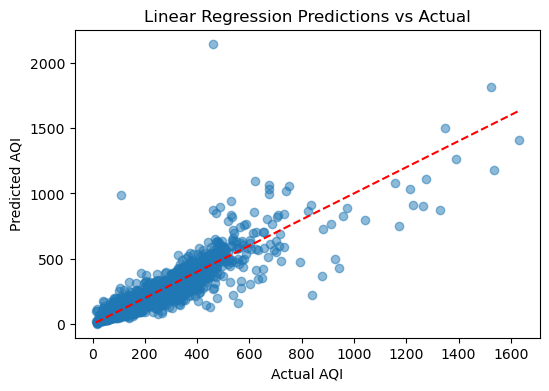

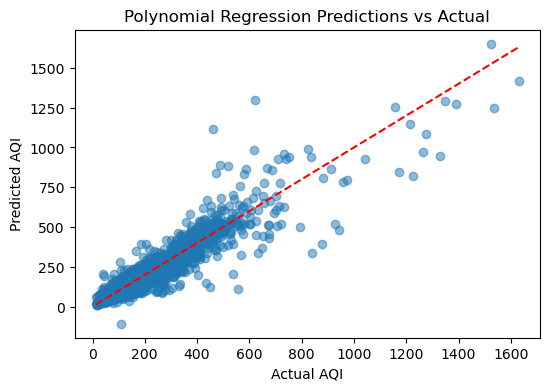

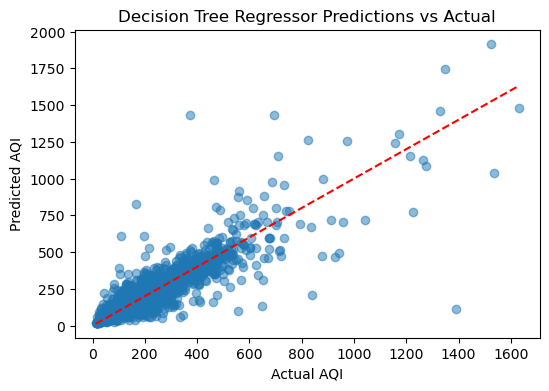

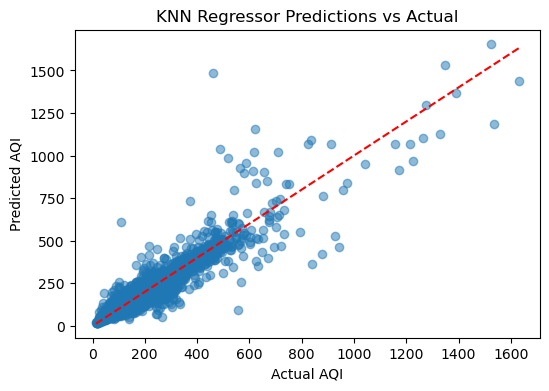

In [15]:
# 6. Plot Regression Predictions
for name, pred in regression_preds.items():
    plt.figure(figsize=(6,4))
    plt.scatter(y_test_reg, pred, alpha=0.5)
    plt.xlabel("Actual AQI")
    plt.ylabel("Predicted AQI")
    plt.title(f"{name} Predictions vs Actual")
    plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], "r--")
    plt.show()

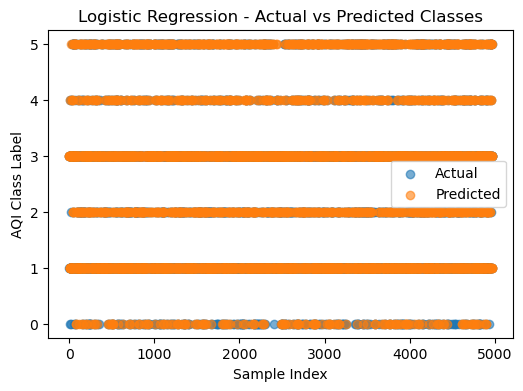

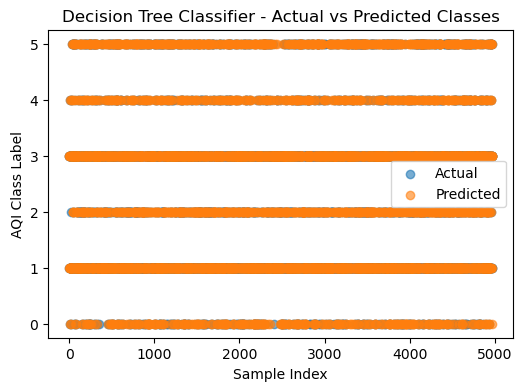

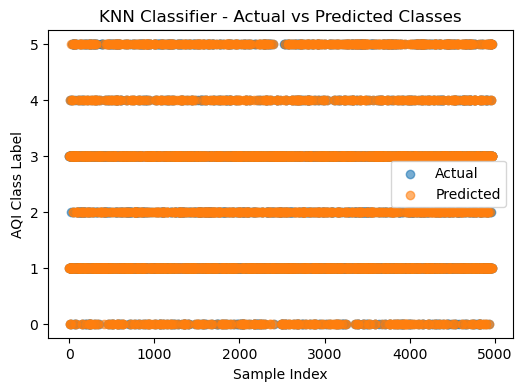

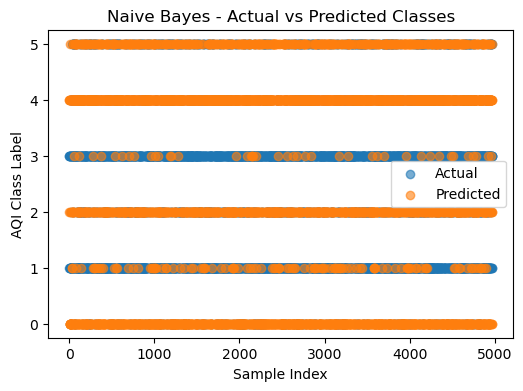

In [16]:
# 7. Plot Classification Predictions
for name, pred in classification_preds.items():
    plt.figure(figsize=(6,4))
    plt.scatter(range(len(y_test_clf)), y_test_clf, label="Actual", alpha=0.6)
    plt.scatter(range(len(pred)), pred, label="Predicted", alpha=0.6)
    plt.title(f"{name} - Actual vs Predicted Classes")
    plt.xlabel("Sample Index")
    plt.ylabel("AQI Class Label")
    plt.legend()
    plt.show()


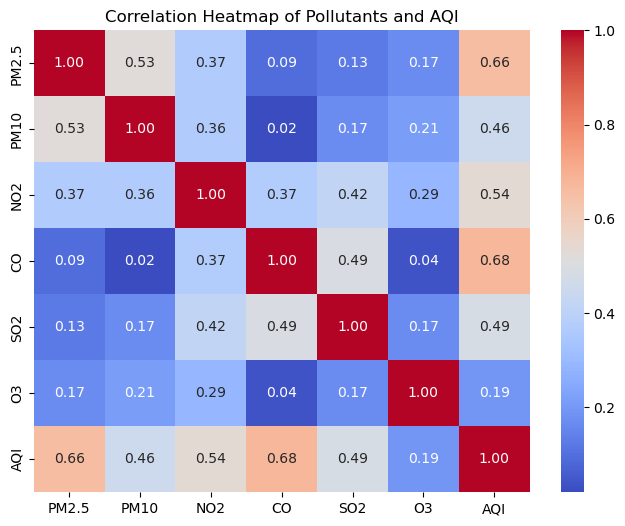

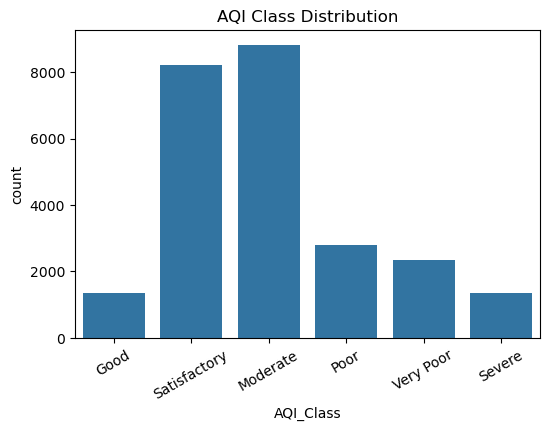

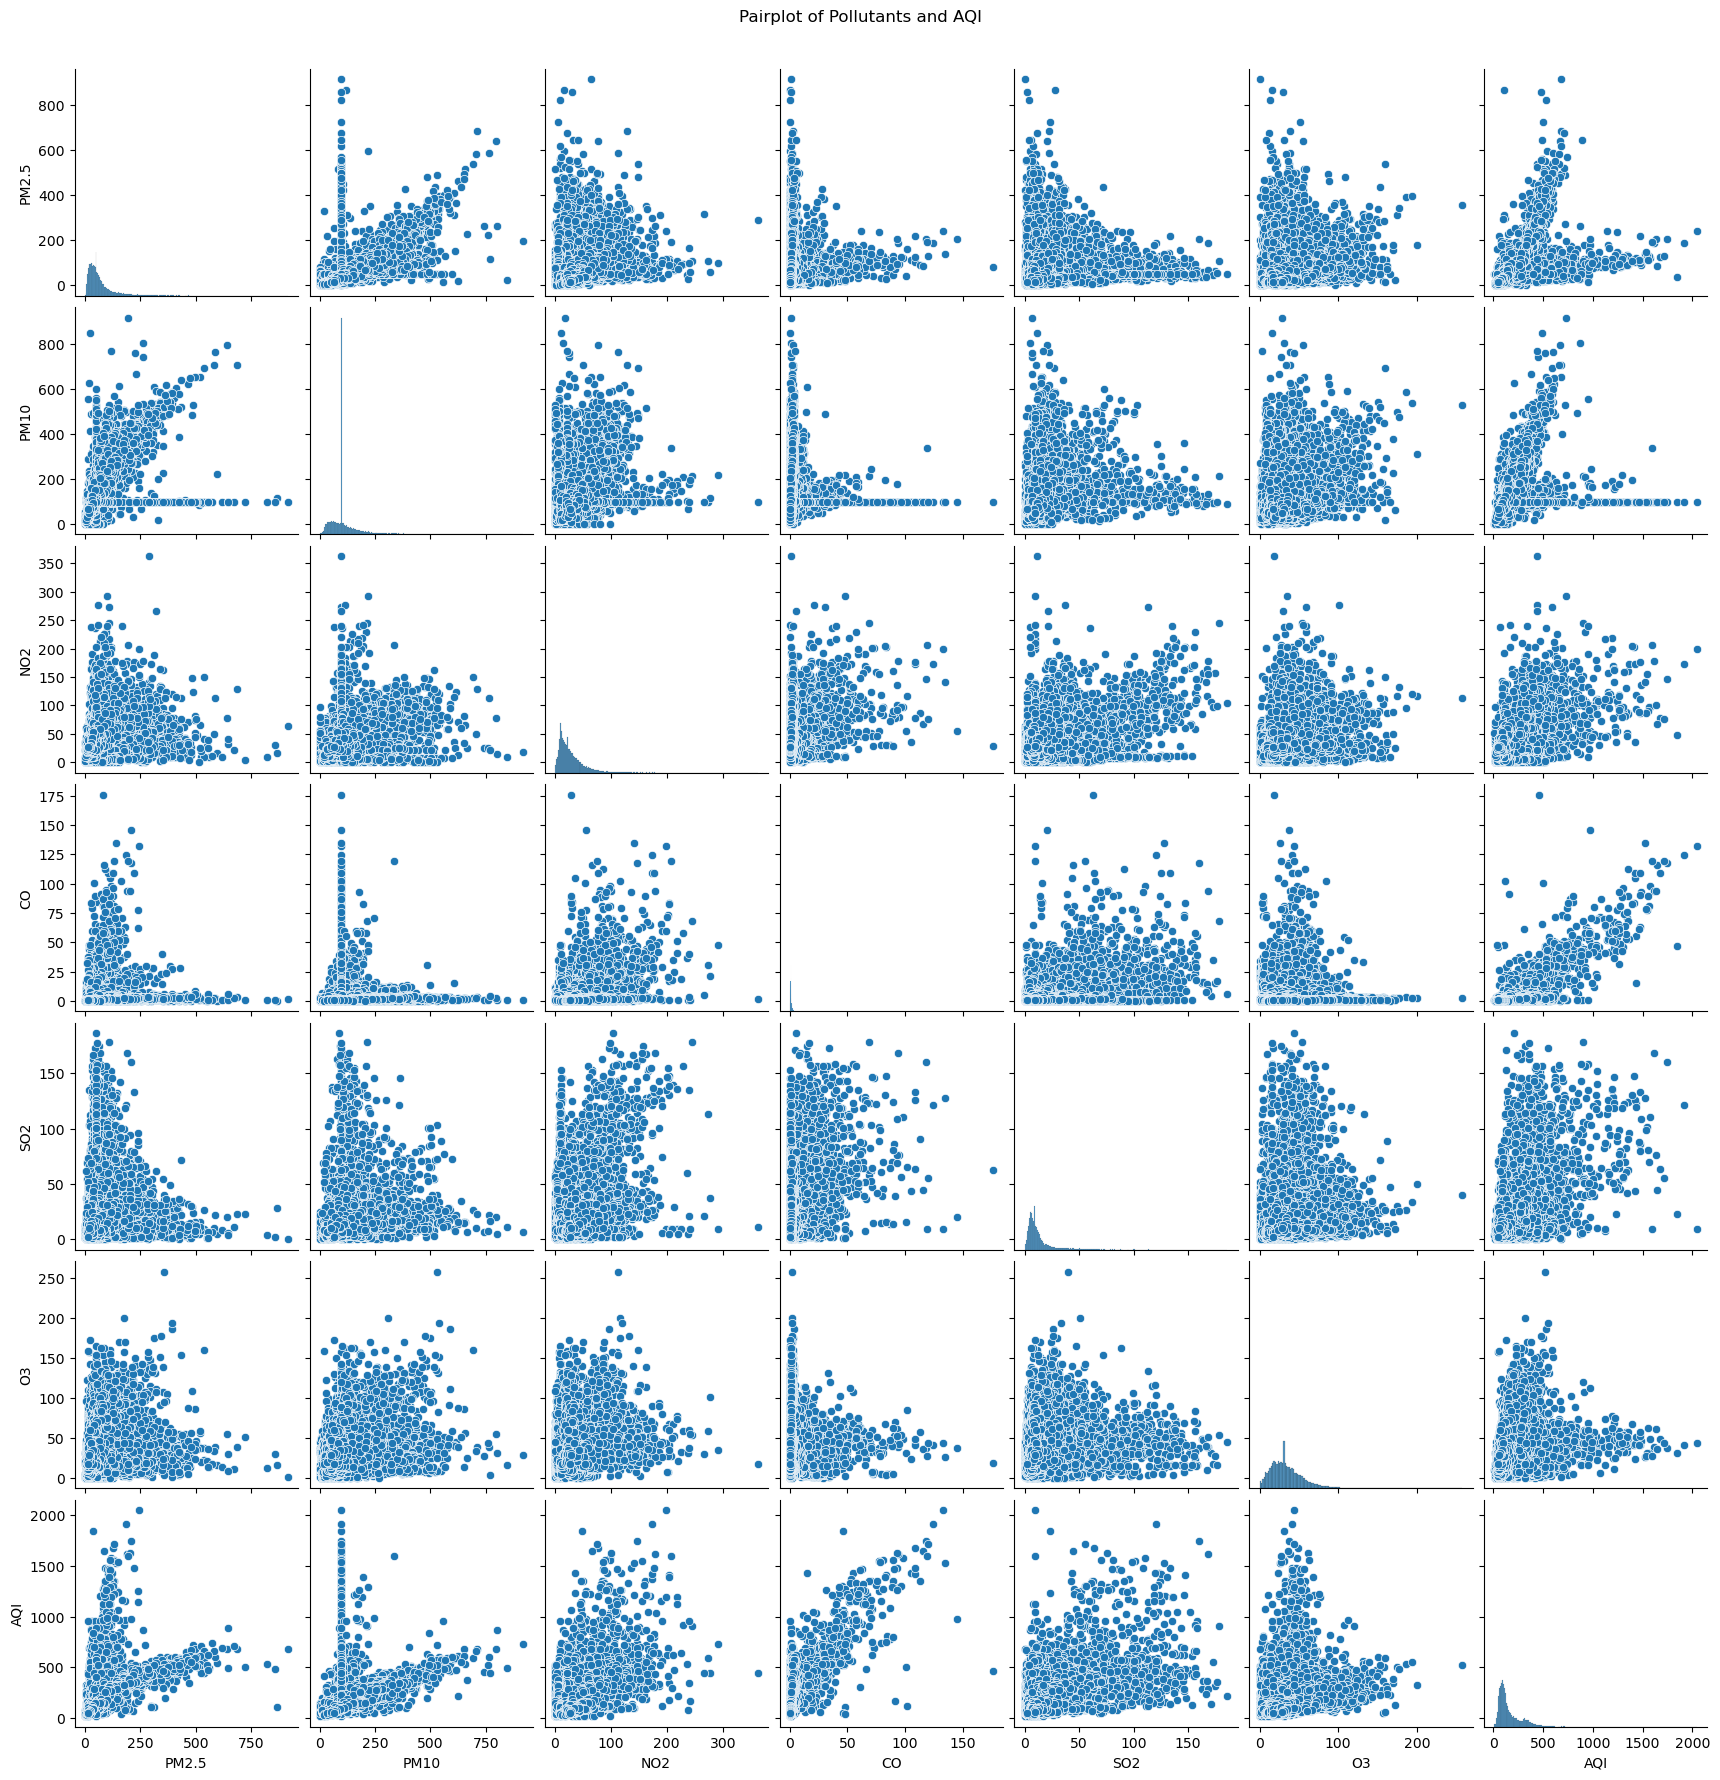

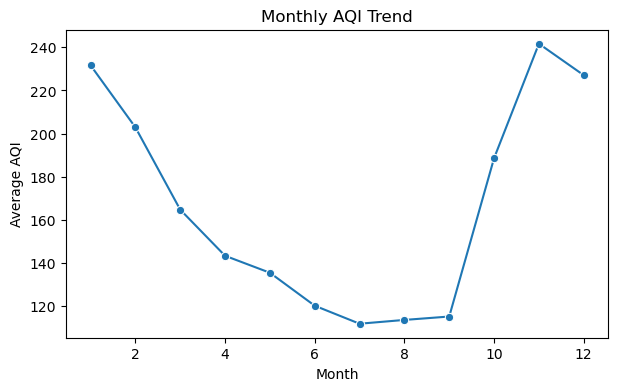

In [17]:
# 8. Other Plots (Optional)
plt.figure(figsize=(8,6))
sns.heatmap(df[pollutants + ["AQI"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Pollutants and AQI")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x=df["AQI_Class"])
plt.title("AQI Class Distribution")
plt.xticks(rotation=30)
plt.show()

sns.pairplot(df[pollutants + ["AQI"]])
plt.suptitle("Pairplot of Pollutants and AQI", y=1.02)
plt.show()

monthly_aqi = df.groupby("month")["AQI"].mean()
plt.figure(figsize=(7,4))
sns.lineplot(x=monthly_aqi.index, y=monthly_aqi.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.title("Monthly AQI Trend")
plt.show()